In [17]:
import numpy as np
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt

In [ ]:
base = "12_28_56"
height = 28
width = 56 
rows = height - 2
columns = width - 2
odarr= np.fromfile(f"./data/{base}_1d.magdir.bin", dtype=np.float32)
refarr= np.fromfile(f"./data/{base}.magdir.bin", dtype=np.float32)
print(rows * columns, rows * columns*2, refarr.shape, odarr.shape)
print(np.any(np.isnan(odarr)))


1404 2808 (2808,) (2808,)
False


In [19]:
rawarr = np.fromfile("./data/0_magdir.bin", dtype=np.float32)
rawarr

array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,  1.02000000e+03,
                   nan,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [20]:
def visualize_vector_field(mag, direction, h, w):
    """
    mag: 2D array of floats (0-255)
    direction: 2D array of floats (-pi to pi)
    """
    MAX_SOBEL_VALUE = np.sqrt(2) * 4 * 255 # when gx,gy = 255; technically over esimate
    mag = mag/MAX_SOBEL_VALUE*255
    
    mag = mag.reshape(h,w)

    direction = direction.reshape(h,w)
    
    # 1. Create an empty HSV image
    # Shape: (height, width, 3)
    hsv = np.zeros((h, w, 3), dtype=np.float32)
    
    # 2. Map Direction to Hue [0, 1]
    # We shift -pi...pi to 0...2pi, then normalize to 0...1
    hsv[..., 0] = (direction + np.pi) / (2 * np.pi)
    
    # 3. Set Saturation to maximum
    hsv[..., 1] = 1.0
    
    # 4. Map Magnitude to Value [0, 1]
    # Ensure it's clipped and normalized
    hsv[..., 2] = np.clip(mag, 0, 255) / 255.0
    
    # 5. Convert HSV to RGB for display
    rgb = hsv_to_rgb(hsv)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.title("Magnitude (Brightness) & Direction (Color)")
    plt.axis('off')
    plt.show()


In [21]:
# raw_mag, raw_dir = rawarr.reshape(2, 45, 70)
# raw_mag = raw_mag[1:-1, 1:-1]
# raw_dir = raw_dir[1:-1, 1:-1]
# print(raw_mag.shape, np.any(np.isnan(raw_mag)), np.any(np.isnan(raw_dir)))
# visualize_vector_field(raw_mag, raw_dir, 68, 43)

In [22]:
mags = odarr[:(rows*columns)]
print(mags.min(), mags.max())
dirs = odarr[(rows*columns):(rows*columns*2)]
print(dirs.min(), dirs.max())
print(np.any(np.isnan(odarr)))
print(odarr[:(rows*columns*2)])

0.0 1017.58344
-3.1372068 3.1415927
False
[0. 0. 0. ... 0. 0. 0.]


In [23]:
# np.allclose(mags, raw_mag.flatten()), np.allclose(dirs,raw_dir.flatten())


In [24]:
ref_mags = refarr[:(rows*columns)]
ref_dirs = refarr[(rows*columns):]
print(ref_mags.min(), ref_mags.max())
print(ref_dirs.min(), ref_dirs.max())

0.0 1017.58344
-3.1372068 3.1415927


In [25]:
def gen(): 
    c = 0
    with np.printoptions(threshold=np.inf, precision=1):
        while True:
            r1 = odarr[c*rows:(c+1)*rows]
            r2 = refarr[c*rows:(c+1)*rows]
            print(c, end=", ")
            c+=1
            if np.all(np.isclose(r1, r2)): 
                continue
            else: 
                print(c)
                print(r1)
                print(r2)
                print(r1 - r2)
                yield
a = gen()

In [26]:
# next(a)

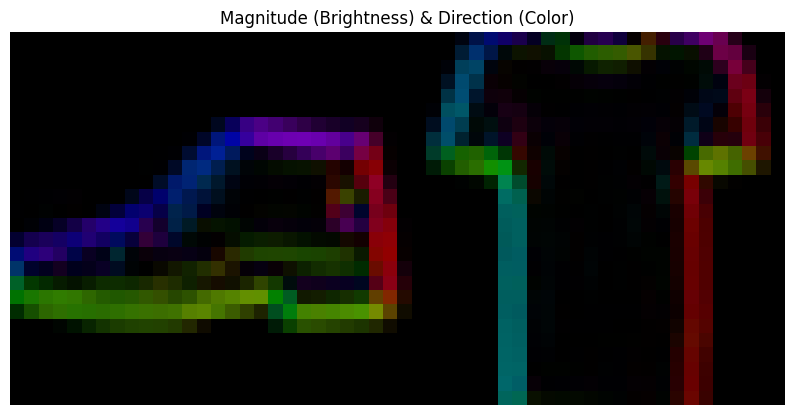

In [27]:
visualize_vector_field(mags, dirs, rows, columns)

In [28]:
np.any(np.isnan(odarr))

np.False_

In [29]:
ref_mags = refarr[:(rows*columns)]
ref_dirs = refarr[(rows*columns):]
print(ref_mags.min(), ref_mags.max())
print(ref_dirs.min(), ref_dirs.max())

0.0 1017.58344
-3.1372068 3.1415927


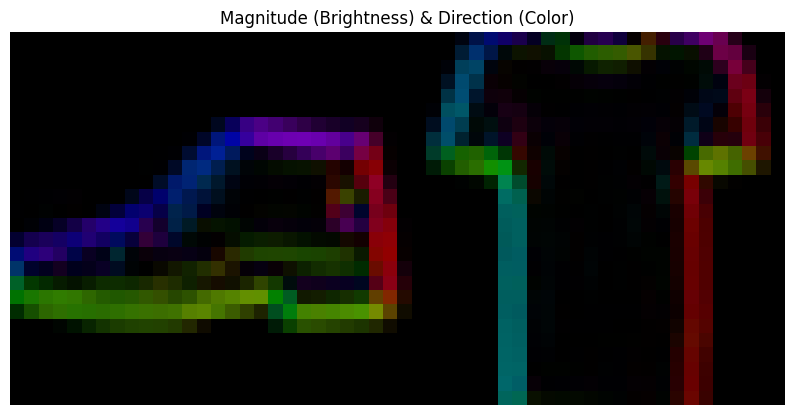

In [30]:
visualize_vector_field(ref_mags , ref_dirs, rows, columns)

In [31]:
mags[ref_mags != mags]

array([], dtype=float32)

In [32]:
ref_mags[ref_mags != mags]

array([], dtype=float32)

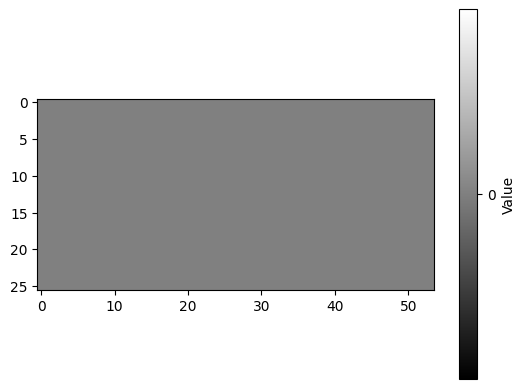

In [33]:
plt.imshow((ref_mags!=mags).reshape(rows,columns), cmap='gray')
plt.colorbar(ticks=[0, 1], label='Value')
plt.show()

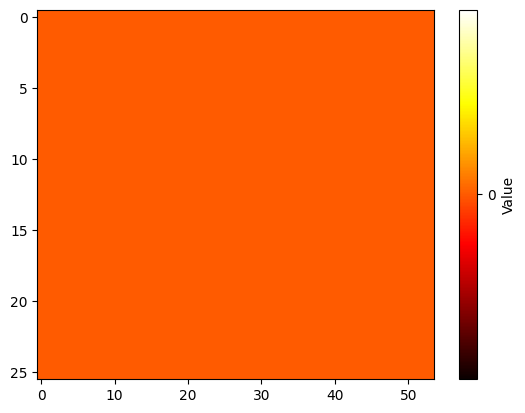

In [34]:
plt.imshow((mags-ref_mags).reshape(rows,columns), cmap='hot', aspect='auto')
plt.colorbar(ticks=[0, 1], label='Value')
plt.show()

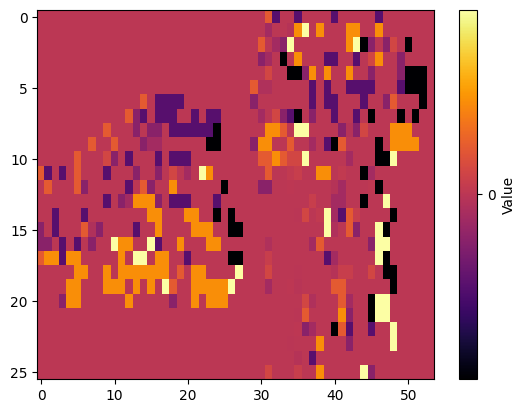

In [35]:
plt.imshow((dirs-ref_dirs).reshape(rows,columns), cmap='inferno', aspect='auto')
plt.colorbar(ticks=[0, 1], label='Value')
plt.show()

In [36]:
print(ref_mags.reshape(43, 68))

ValueError: cannot reshape array of size 1404 into shape (43,68)

In [ ]:
print(mags.reshape(43, 68))

[[  0.         0.         0.       ...   0.         0.         0.      ]
 [  0.         0.         0.       ...   0.         0.         0.      ]
 [  0.         0.         0.       ...   0.         0.         0.      ]
 ...
 [  4.        29.15476   17.720045 ...  10.770329   2.828427  10.      ]
 [  2.828427  21.954498 169.14491  ...  17.029387  52.63079   27.018513]
 [257.72076  743.4218   493.7793   ... 179.13683  205.13898  280.04642 ]]


# image reading

In [ ]:
read_in = np.fromfile("./data/local_in.bin", np.uint8)
read_in.reshape(47, 72)

array([[255, 255, 255, ...,   0,   0,   0],
       [  0,   0,   0, ..., 255,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [192, 188, 161, ..., 235, 208, 193],
       [211, 211, 255, ..., 180, 193, 111],
       [  0,   2,   0, ..., 255, 255, 255]], shape=(47, 72), dtype=uint8)

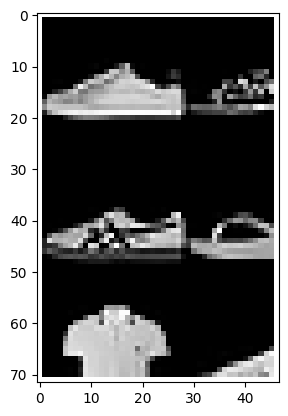

In [ ]:
plt.imshow(read_in.reshape(72, 47), cmap='grey', vmin=0, vmax=255)
plt.show()

In [ ]:
act_in = np.fromfile("./data/dim_70_45.img.bin", np.uint8)

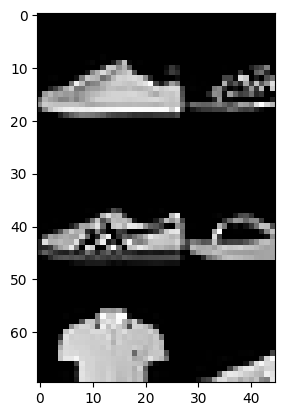

In [ ]:
plt.imshow(act_in.reshape(70,45), cmap='grey', vmin=0, vmax=255)
plt.show()